170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Data Shape: (50000, 32, 32, 3)
Testing Data Shape: (10000, 32, 32, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 158s 495ms/step - accuracy: 0.3444 - loss: 1.7773 - val_accuracy: 0.4702 - val_loss: 1.4859
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 200s 490ms/step - accuracy: 0.5066 - loss: 1.3701 - val_accuracy: 0.5647 - val_loss: 1.2245
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 203s 493ms/step - accuracy: 0.5713 - loss: 1.2012 - val_accuracy: 0.6090 - val_loss: 1.1024
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 153s 488ms/step - accuracy: 0.6182 - loss: 1.0811 - val_accuracy: 0.6521 - val_loss: 0.9930
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 203s 491ms/step - accuracy: 0.6531 - loss: 0.9840 - val_accuracy: 0.6509 - val_loss: 0.9872
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 152s 484ms/step - accuracy: 0.6836 - loss: 0.9061 - val_accuracy: 0.6970 - val_loss: 0.8772
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 201s 482ms/step - accuracy: 0.7042 - loss: 0.8434 - val_accuracy: 0.7124 - val_loss: 0.8387
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 152s 486ms/step - accuracy: 0.7282 -

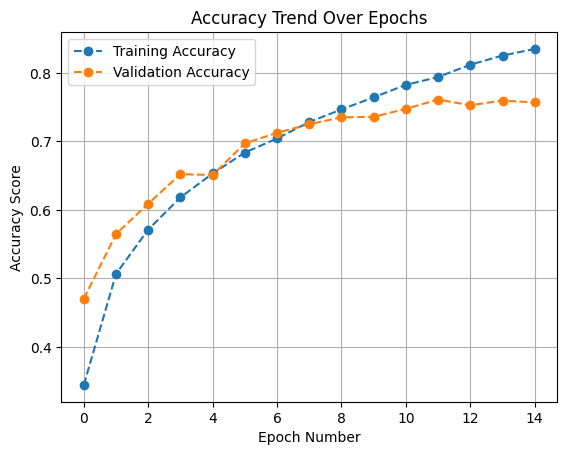

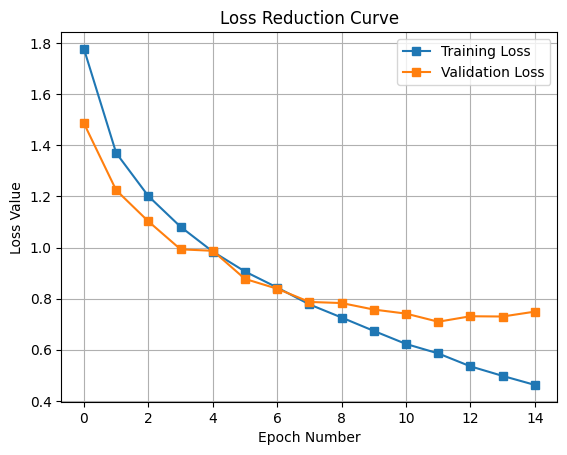


Final Test Results
-------------------
Accuracy: 74.06%
Loss: 0.7826
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


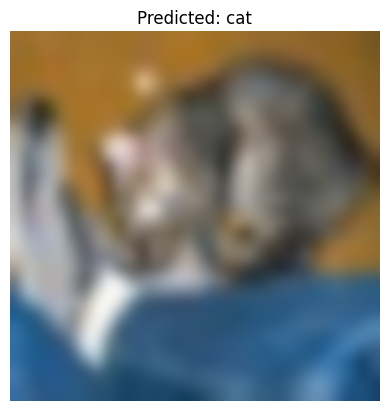

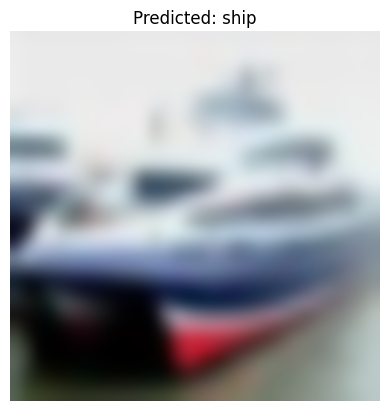

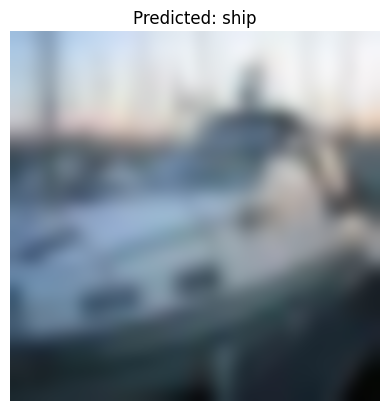

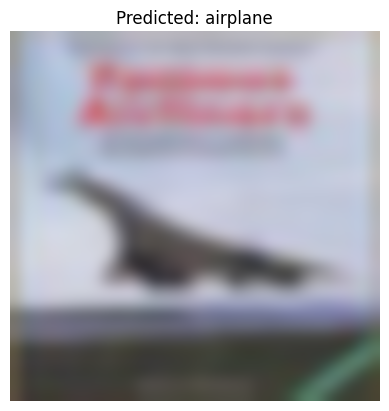

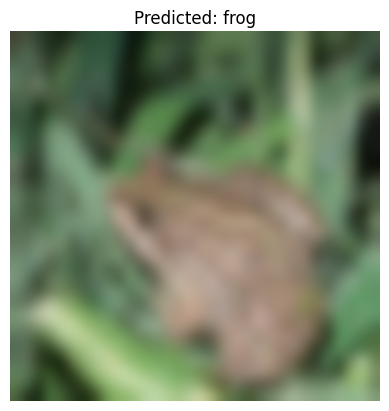

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Load & Preprocess Data
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape labels
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)


# 2. Build CNN Model

model = models.Sequential([

    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

# 3. Compile Model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# 4. Train Model

history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# 5. Plot Accuracy Graph

plt.figure()
plt.plot(history.history['accuracy'], '--o', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], '--o', label='Validation Accuracy')

plt.title('Accuracy Trend Over Epochs')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid()
plt.show()

# 6. Plot Loss Graph

plt.figure()
plt.plot(history.history['loss'], '-s', label='Training Loss')
plt.plot(history.history['val_loss'], '-s', label='Validation Loss')

plt.title('Loss Reduction Curve')
plt.xlabel('Epoch Number')
plt.ylabel('Loss Value')
plt.legend()
plt.grid()
plt.show()

# 7. Evaluate Model

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("\nFinal Test Results")
print("-------------------")
print(f"Accuracy: {test_acc*100:.2f}%")
print(f"Loss: {test_loss:.4f}")

# 8. Predictions (Visualization)
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

predictions = model.predict(x_test[:5])

for i in range(5):
    plt.imshow(x_test[i], interpolation='bicubic')
    plt.title(f"Predicted: {class_names[np.argmax(predictions[i])]}")
    plt.axis('off')
    plt.show()